In [4]:
"""
Population-dynamical long-range Ising RG with three-state couplings:
    J_r in { 0, +|J0|/r^a, -|J0|/r^a }

Parameters
----------
p      : fraction of ANTIFERROMAGNETIC (negative) couplings among NON-ZERO bonds
r_frac : fraction of ZERO couplings among all distances r = 1..D

So the probabilities per distance are
    P(J_r = 0)              = r_frac
    P(J_r = -|J0|/r^a)      = (1 - r_frac) * p
    P(J_r = +|J0|/r^a)      = (1 - r_frac) * (1 - p)

Exact fixed-composition sampling (not i.i.d. Bernoulli) is used, to match
the style of the existing staggered population-dynamics code.

Geometry: staggered two-cell geometry (imports from decimation_staggered).
RG mode: head-only, shrinking vector. No tail reconstruction.
"""

import numpy as np
import matplotlib.pyplot as plt
from numba import njit

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'lib')))

from utils import _xorshift64star_next
from decimation_staggered import (
    required_initial_max_distance,
    r_max,
    log_Rpp_Rpm,
)


# ----------------------------
# Deterministic Fisher-Yates on a length-D array (indices 1..D), Numba-safe
# ----------------------------

@njit(cache=True)
def _fisher_yates_1toD(arr, seed_mix):
    """
    In-place Fisher-Yates shuffle of arr[1..len(arr)-1], leaving arr[0] alone.
    `seed_mix` is a uint64 already mixed by the caller.
    """
    state = seed_mix
    if state == np.uint64(0):
        state = np.uint64(0xD1B54A32D192ED03)
    n = arr.shape[0] - 1  # number of shuffle-eligible entries, indices 1..n
    for i in range(n, 1, -1):
        state, rnd = _xorshift64star_next(state)
        j = 1 + int(rnd % np.uint64(i))  # j in [1, i]
        tmp = arr[i]
        arr[i] = arr[j]
        arr[j] = tmp


# ----------------------------
# Three-state coupling sign/zero pattern
# ----------------------------

@njit(cache=True)
def generate_states(D, p, r_frac, seed):
    """
    Return an int8 array `state[0..D]` with state[0]=0 unused, and for r=1..D:
        state[r] =  0 with exact count floor(r_frac * D)
        state[r] = -1 with exact count floor(p * (D - n_zero))
        state[r] = +1 with the remainder

    Then shuffled (Fisher-Yates, deterministic by seed).
    """
    state_arr = np.zeros(D + 1, dtype=np.int8)

    n_zero  = int(r_frac * D)
    n_nz    = D - n_zero
    n_minus = int(p * n_nz)
    n_plus  = n_nz - n_minus

    idx = 1
    for _ in range(n_zero):
        state_arr[idx] = 0
        idx += 1
    for _ in range(n_minus):
        state_arr[idx] = -1
        idx += 1
    for _ in range(n_plus):
        state_arr[idx] = 1
        idx += 1

    seed_mix = np.uint64(seed) ^ np.uint64(0x9E3779B97F4A7C15)
    _fisher_yates_1toD(state_arr, seed_mix)
    return state_arr


@njit(cache=True)
def build_J_dilute_signed(J0, a, D, p, r_frac, seed):
    """
    Initial coupling vector with three-state distribution.
    J[0] = 0. For r>=1, J[r] = state[r] * J0 / r^a, where state[r] in {-1,0,+1}.
    """
    states = generate_states(D, p, r_frac, seed)
    J = np.zeros(D + 1, dtype=np.float64)
    for r in range(1, D + 1):
        if states[r] != 0:
            J[r] = (float(states[r]) * J0) / (r ** a)
        # else leave as 0.0
    return J


# ----------------------------
# Diagnostics on a J vector
# ----------------------------

@njit(cache=True)
def fractions(J, zero_tol=1e-14):
    """
    Return (p_eff, r_eff) for J[1..D]:
        r_eff = fraction of |J_r| <= zero_tol
        p_eff = fraction of J_r < 0 among the non-zero entries
    """
    D = J.shape[0] - 1
    if D <= 0:
        return 0.0, 0.0
    n_zero = 0
    n_neg = 0
    n_nz = 0
    for r in range(1, D + 1):
        if abs(J[r]) <= zero_tol:
            n_zero += 1
        else:
            n_nz += 1
            if J[r] < 0.0:
                n_neg += 1
    r_eff = n_zero / D
    p_eff = (n_neg / n_nz) if n_nz > 0 else 0.0
    return p_eff, r_eff


# ----------------------------
# One RG step: staggered, head-only, shrinking vector
# ----------------------------

@njit(cache=True)
def rg_step(J):
    """
    One head-only staggered RG step. No tail reconstruction.
    Output length = r_max(D) + 1, so the vector shrinks each iteration.

    Uses exactly the same per-distance recursion as the existing code:
        J'_r = 0.5 * (log R_++ - log R_+-)
    with R_++ and R_+- coming from decimation_staggered.log_Rpp_Rpm.
    Zero entries in J are handled implicitly: a zero bond contributes e^0=1
    inside the cell-pair partition sums, so nothing special is needed here.
    """
    D = J.shape[0] - 1
    rstop = r_max(D)

    J_new = np.zeros(rstop + 1, dtype=np.float64)
    for rr in range(1, rstop + 1):
        log_pp, log_pm = log_Rpp_Rpm(rr, J)
        J_new[rr] = 0.5 * (log_pp - log_pm)
    return J_new


# ----------------------------
# RG flow
# ----------------------------

def generate_rg_flow(J0, a, D, n_steps, p, r_frac, seed=12345):
    """
    Build dilute signed initial condition and iterate `n_steps` shrinking RG steps.
    Returns a list of J vectors [J^(0), J^(1), ..., J^(n_steps)] of decreasing length.
    """
    J = build_J_dilute_signed(J0, a, D, p, r_frac, seed)
    flow = [J.copy()]
    for _ in range(n_steps):
        J = rg_step(J)
        flow.append(J.copy())
    return flow


# ----------------------------
# Plot helper
# ----------------------------

def plot_rg_flow(flow, distances_to_plot=None, title=None, ax=None):
    """
    Plot J_r vs RG step k for a list of distances. Skips a (step, r) pair
    if r exceeds the current vector length at that step (due to shrinkage).
    """
    if distances_to_plot is None:
        distances_to_plot = [1, 2, 3, 4, 5]

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
    else:
        fig = ax.figure

    for rr in distances_to_plot:
        steps_ok = []
        vals = []
        for k, J in enumerate(flow):
            if 1 <= rr <= (len(J) - 1):
                steps_ok.append(k)
                vals.append(J[rr])
        if len(vals) > 0:
            ax.plot(steps_ok, vals, marker='o', label=f"$r={rr}$")

    ax.axhline(0.0, color='k', lw=0.5, alpha=0.5)
    ax.set_xlabel(r"RG iteration $k$")
    ax.set_ylabel(r"Coupling $J_r$")
    if title is not None:
        ax.set_title(title)
    ax.legend(title="distance", fontsize=9)
    fig.tight_layout()
    return fig, ax


# ----------------------------
# Simple phase-sink classifier
# ----------------------------

def classify_sink(
    flow,
    track_r=(2, 3, 4, 5),
    eval_step=None,
    thr_dis=1e-2,
    thr_ord=1e2,
):
    """
    Classify the phase sink from a flow:
      - 'disorder'  : all |J_r| < thr_dis for r in track_r
      - 'ferro'     : all  J_r > thr_ord  for r in track_r
      - 'antiferro' : all  J_r < -thr_ord for r in track_r
      - 'spinglass' : at least one |J_r| > thr_ord but signs are mixed
                      (i.e. the coupling grows but not coherently)
      - 'undetermined' : none of the above / tracked r unavailable
    """
    if eval_step is None:
        eval_step = len(flow) - 1
    eval_step = max(0, min(eval_step, len(flow) - 1))
    J_eval = flow[eval_step]
    D_eval = len(J_eval) - 1

    vals = []
    for rr in track_r:
        if not (1 <= rr <= D_eval):
            return "undetermined", {
                "reason": "missing_tracked_distance",
                "missing_r": rr, "D_eval": D_eval, "eval_step": eval_step,
            }
        vals.append(float(J_eval[rr]))
    vals = np.array(vals)
    absv = np.abs(vals)

    if np.all(absv < thr_dis):
        return "disorder", {"eval_step": eval_step, "vals": vals}
    if np.all(vals > thr_ord):
        return "ferro", {"eval_step": eval_step, "vals": vals}
    if np.all(vals < -thr_ord):
        return "antiferro", {"eval_step": eval_step, "vals": vals}
    if np.any(absv > thr_ord):
        # at least one coupling is large, but not all coherent in sign
        return "spinglass", {"eval_step": eval_step, "vals": vals}
    return "undetermined", {"eval_step": eval_step, "vals": vals}


# ----------------------------
# Transfer matrix at a single distance
# ----------------------------

def construct_transfer_matrix(J, r, normalize=True):
    """
    2x2 transfer matrix for the spin-1/2 Ising bond at distance r:
        T(J_r) = [[exp(J_r), exp(-J_r)],
                  [exp(-J_r), exp(J_r)]]
    Normalized by its maximum entry when normalize=True.
    """
    if r >= len(J):
        raise ValueError(
            f"distance r={r} > max available {len(J)-1}"
        )
    Jr = float(J[r])
    T = np.array(
        [[np.exp(Jr),  np.exp(-Jr)],
         [np.exp(-Jr), np.exp(Jr)]],
        dtype=np.float64,
    )
    if normalize:
        T = T / T.max()
    return T


# ----------------------------
# RG flow with optional transfer-matrix trace at a single distance
# ----------------------------

def generate_rg_flow_with_TM(
    J0, a, D, n_steps, p, r_frac,
    seed=12345,
    trace_TM=False,
    TM_r=1,
    normalize_TM=True,
):
    """
    Build the dilute signed initial vector and iterate `n_steps` head-only
    staggered RG steps. If trace_TM, also record the 2x2 transfer matrix
    at distance TM_r (a single int) at every step where it fits.

    Returns
    -------
    J_list  : list of np.ndarray, one per step (decreasing length).
    TM_list : list of np.ndarray (2,2) or None if trace_TM is False.
              Step k's matrix is at TM_list[k]. If TM_r falls outside the
              vector at some step, that step contributes None.
    """
    J = build_J_dilute_signed(J0, a, D, p, r_frac, seed)

    J_list = [J.copy()]
    if trace_TM:
        TM_list = []
        if TM_r < len(J):
            TM_list.append(construct_transfer_matrix(J, TM_r, normalize=normalize_TM))
        else:
            TM_list.append(None)
    else:
        TM_list = None

    for _ in range(n_steps):
        J = rg_step(J)
        J_list.append(J.copy())
        if trace_TM:
            if TM_r < len(J):
                TM_list.append(construct_transfer_matrix(J, TM_r, normalize=normalize_TM))
            else:
                TM_list.append(None)

    return J_list, TM_list


# ----------------------------
# Pretty-print transfer matrices: one block per step, blank line between
# ----------------------------

def print_TM_trace(TM_list, decimals=4):
    """
    Print transfer matrices, one per RG step, separated by a blank line.
    None entries (r out of range at that step) are reported succinctly.
    """
    if TM_list is None:
        print("(no TM trace was recorded)")
        return
    for k, T in enumerate(TM_list):
        print(f"step {k}:")
        if T is None:
            print("  (r out of range)")
        else:
            for row in T:
                print("  " + "  ".join(f"{v:.{decimals}f}" for v in row))
        print()


# ----------------------------
# Classify a 2x2 normalized TM using sink direction
# ----------------------------

def classify_TM_by_direction(
    T_current,
    T_prev,
    thresh_one=0.8,
    thresh_zero=0.2,
):
    """
    Direction-aware classification of a normalized 2x2 Ising transfer matrix.

    Ferro sink:
        [[1, 0],
         [0, 1]]

    Antiferro sink:
        [[0, 1],
         [1, 0]]

    Disorder sink:
        [[1, 1],
         [1, 1]]

    A sink is accepted only if:
      - entries expected to become 1 are already large and increasing,
      - entries expected to become 0 are already small and decreasing.
    """
    if T_current is None or T_prev is None:
        return "undetermined"

    diff = T_current - T_prev

    def matches_sink(one_positions, zero_positions):
        for i, j in one_positions:
            if T_current[i, j] < thresh_one:
                return False
            if diff[i, j] < 0:
                return False

        for i, j in zero_positions:
            if T_current[i, j] > thresh_zero:
                return False
            if diff[i, j] >= 0:
                return False

        return True

    one_ferro = [(0, 0), (1, 1)]
    zero_ferro = [(0, 1), (1, 0)]

    one_antiferro = [(0, 1), (1, 0)]
    zero_antiferro = [(0, 0), (1, 1)]

    one_disorder = [(0, 0), (0, 1), (1, 0), (1, 1)]
    zero_disorder = []

    if matches_sink(one_ferro, zero_ferro):
        return "ferro"

    if matches_sink(one_antiferro, zero_antiferro):
        return "antiferro"

    if matches_sink(one_disorder, zero_disorder):
        return "disorder"

    return "undetermined"


# ----------------------------
# Direction-aware phase determination with early stopping
# ----------------------------

def determine_phase_at_directional_early_stop(
    J0, a, p, r_frac,
    max_dist_final,
    n_steps_total,
    seed=12345,
    TM_rs=(2, 3, 4),
    min_check_step=3,
    thresh_one=0.8,
    thresh_zero=0.2,
):
    """
    Generate RG flow and classify phases from successive transfer matrices.

    After min_check_step, compare

        T_current(r) - T_previous(r)

    for every r in TM_rs.

    If all chosen distances classify to the same non-undetermined sink,
    stop early and return that phase.
    """
    TM_rs = tuple(TM_rs)

    D0 = required_initial_max_distance(max_dist_final, n_steps_total)
    J = build_J_dilute_signed(J0, a, D0, p, r_frac, seed)

    flow = [J.copy()]

    TM_history = []

    # initial transfer matrices
    TM0 = {}
    for r in TM_rs:
        if r < len(J):
            TM0[r] = construct_transfer_matrix(J, r, normalize=True)
    TM_history.append(TM0)

    for step in range(1, n_steps_total + 1):
        J = rg_step(J)
        flow.append(J.copy())

        D_now = len(J) - 1

        if any(r > D_now for r in TM_rs):
            return "undetermined", {
                "reason": "tracked_distance_out_of_range",
                "stop_step": step,
                "D_now": D_now,
                "TM_rs": TM_rs,
                "flow": flow,
                "TM_history": TM_history,
                "J_final": J.copy(),
            }

        TM_current = {}
        for r in TM_rs:
            TM_current[r] = construct_transfer_matrix(J, r, normalize=True)

        TM_history.append(TM_current)

        if step < min_check_step:
            continue

        TM_prev = TM_history[-2]

        phases = []

        for r in TM_rs:
            ph = classify_TM_by_direction(
                T_current=TM_current[r],
                T_prev=TM_prev[r],
                thresh_one=thresh_one,
                thresh_zero=thresh_zero,
            )
            phases.append(ph)

        if len(set(phases)) == 1 and phases[0] != "undetermined":
            return phases[0], {
                "reason": "directional_early_sink_reached",
                "stop_step": step,
                "TM_rs": TM_rs,
                "TM_phases": phases,
                "TM_current": TM_current,
                "TM_prev": TM_prev,
                "TM_history": TM_history,
                "flow": flow,
                "J_final": J.copy(),
            }

    return "undetermined", {
        "reason": "max_steps_reached",
        "stop_step": n_steps_total,
        "TM_rs": TM_rs,
        "TM_history": TM_history,
        "flow": flow,
        "J_final": J.copy(),
    }


# ----------------------------
# Direction-aware (p, T) scan
# ----------------------------

def scan_phase_sinks_p_T_directional_early_stop(
    p_values,
    T_values,
    a,
    r_frac,
    max_dist_final,
    n_steps_total,
    TM_rs=(2, 3, 4),
    min_check_step=3,
    seed=12345,
    thresh_one=0.8,
    thresh_zero=0.2,
    progress="text",
    report_every=None,
    return_info=False,
):
    """
    Scan a (p, T) grid at fixed (a, r_frac), using directional
    transfer-matrix sink classification.

    At each point:
      J0 = 1 / T
      RG flow is generated internally
      successive transfer matrices are compared after min_check_step
      early stop occurs if all chosen distances agree on the same sink
    """
    import time

    p_values = np.asarray(p_values, dtype=np.float64)
    T_values = np.asarray(T_values, dtype=np.float64)

    bins = {
        "ferro":        [],
        "antiferro":    [],
        "disorder":     [],
        "undetermined": [],
    }

    info_grid = {}

    total = len(p_values) * len(T_values)

    use_tqdm = False
    pbar = None

    if progress == "tqdm":
        try:
            from tqdm.auto import tqdm
            pbar = tqdm(
                total=total,
                desc=f"directional scan a={a:g}, r_frac={r_frac:g}"
            )
            use_tqdm = True
        except ImportError:
            progress = "text"

    if report_every is None:
        report_every = max(1, total // 20)

    def _fmt_time(s):
        if s < 0 or not np.isfinite(s):
            return "?"
        m, s = divmod(int(s), 60)
        h, m = divmod(m, 60)
        return f"{h:d}:{m:02d}:{s:02d}" if h else f"{m:d}:{s:02d}"

    t0 = time.time()
    k = 0

    for p in p_values:
        for T in T_values:
            J0 = 1.0 / float(T)

            phase, info = determine_phase_at_directional_early_stop(
                J0=J0,
                a=a,
                p=float(p),
                r_frac=float(r_frac),
                max_dist_final=max_dist_final,
                n_steps_total=n_steps_total,
                seed=int(seed),
                TM_rs=TM_rs,
                min_check_step=min_check_step,
                thresh_one=thresh_one,
                thresh_zero=thresh_zero,
            )

            if phase not in bins:
                phase = "undetermined"

            bins[phase].append((p, T))

            if return_info:
                info_grid[(float(p), float(T))] = info

            k += 1

            if use_tqdm:
                pbar.set_postfix(
                    F=len(bins["ferro"]),
                    AF=len(bins["antiferro"]),
                    D=len(bins["disorder"]),
                    U=len(bins["undetermined"]),
                    refresh=False,
                )
                pbar.update(1)

            elif progress == "text" and (k % report_every == 0 or k == total):
                elapsed = time.time() - t0
                rate = k / elapsed if elapsed > 0 else 0.0
                eta = (total - k) / rate if rate > 0 else float("inf")

                print(
                    f"  [{k:>{len(str(total))}}/{total}] "
                    f"{100.0 * k / total:5.1f}%  "
                    f"elapsed {_fmt_time(elapsed)}  ETA {_fmt_time(eta)}  "
                    f"F={len(bins['ferro'])} "
                    f"AF={len(bins['antiferro'])} "
                    f"D={len(bins['disorder'])} "
                    f"U={len(bins['undetermined'])}",
                    flush=True,
                )

    if use_tqdm:
        pbar.close()

    def _arr(lst):
        return np.array(lst, dtype=np.float64).reshape((-1, 2))

    result = (
        _arr(bins["ferro"]),
        _arr(bins["antiferro"]),
        _arr(bins["disorder"]),
        _arr(bins["undetermined"]),
    )

    if return_info:
        return result + (info_grid,)

    return result


def plot_phase_points_p_T(
    ferro_points,
    antiferro_points,
    disorder_points,
    undetermined_points,
    a=None,
    r_frac=None,
    title=None,
    marker_size=18,
    ax=None,
    show=True,
):
    """
    Scatter plot in the (p, T) plane. Square markers, fixed colors per phase.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(7.5, 5.5))
    else:
        fig = ax.figure

    style = {
        "ferro":        ("tab:blue",   "Ferromagnetic",     ferro_points),
        "antiferro":    ("tab:red",    "Antiferromagnetic", antiferro_points),
        "disorder":     ("tab:gray",   "Disorder",          disorder_points),
        "undetermined": ("tab:orange", "Undetermined",      undetermined_points),
    }
    for _, (color, label, arr) in style.items():
        if arr.size:
            ax.scatter(arr[:, 0], arr[:, 1],
                       s=marker_size, marker='s', c=color, label=label)

    ax.set_xlabel(r"Antiferromagnetic bond concentration $p$")
    ax.set_ylabel(r"Temperature $1/J$")
    if title is None and (a is not None) and (r_frac is not None):
        title = rf"Phase diagram   $a={a:g}$,   $r_{{\rm frac}}={r_frac:g}$"
    if title is not None:
        ax.set_title(title)
    ax.legend(frameon=True, loc="best", fontsize=9)
    fig.tight_layout()
    if show:
        plt.show()
    return fig, ax

(<Figure size 700x500 with 1 Axes>,
 <Axes: xlabel='RG iteration $k$', ylabel='Coupling $J_r$'>)

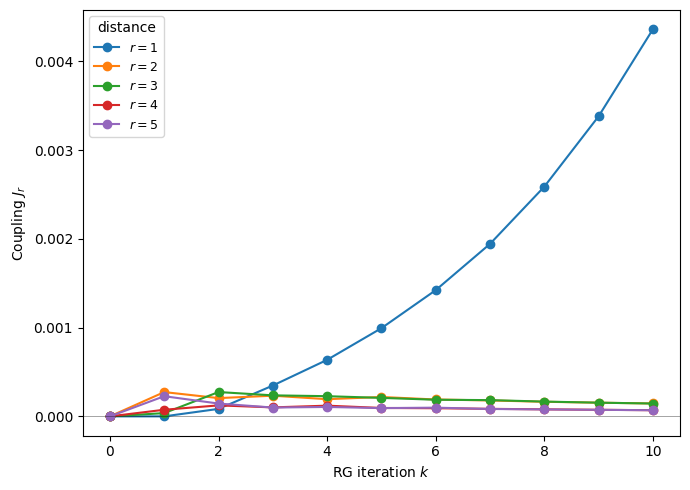

In [5]:
J_list, TM_list = generate_rg_flow_with_TM(
    J0=.001,
    a=0.8,
    D=required_initial_max_distance(max_dist_final=5, n_steps=10),
    n_steps=10,
    p=0.0,
    r_frac=0.6,
    seed=19,
    trace_TM=True,
    TM_r=1,
    normalize_TM=True
)

#print_TM_trace(TM_list)

plot_rg_flow(J_list, distances_to_plot=[1, 2, 3, 4, 5], title=None, ax=None)

Scanning directional (p, T) phase diagram at a=1.0, r_frac=0.5
  classification: successive TMs at r=(2,)
  thresholds: one>0.9, zero<0.1
  grid: |p|=26 x |T|=26 = 676 points







































































































































































































































































































































































































































































































































































































































































































directional scan a=1, r_frac=0.5: 100%|██████████| 676/676 [06:27<00:00,  1.74it/s, AF=12, D=551, F=89, U=24]


  ferro:        89
  antiferro:    12
  disorder:     551
  undetermined: 24


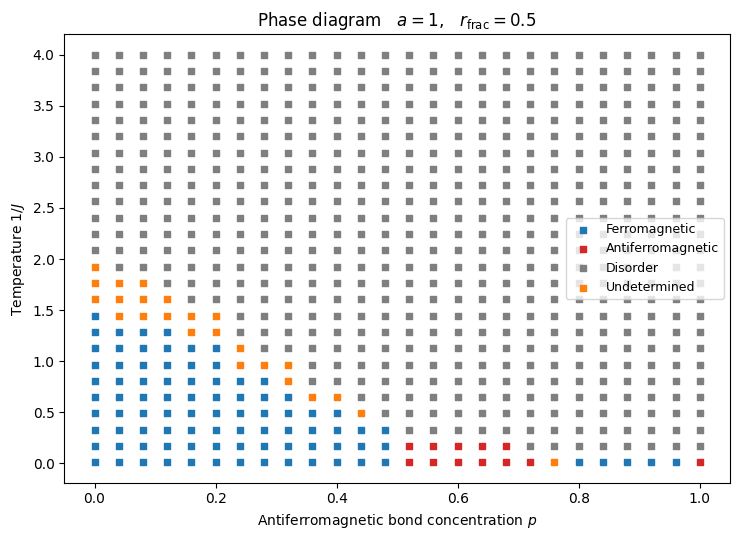

(<Figure size 750x550 with 1 Axes>,
 <Axes: title={'center': 'Phase diagram   $a=1$,   $r_{\\rm frac}=0.5$'}, xlabel='Antiferromagnetic bond concentration $p$', ylabel='Temperature $1/J$'>)

In [ ]:
# ---- parameters ----
a               = 1.0
r_frac          = 0.5
p_values        = np.linspace(0.0, 1.0, 26)
T_values        = np.linspace(0.01, 4.0, 26)
max_dist_final  = 20
n_steps_total   = 10
seed            = 19

TM_rs           = (2,)
min_check_step  = 3

thresh_one      = 0.9
thresh_zero     = 0.1

print(f"Scanning directional (p, T) phase diagram at a={a}, r_frac={r_frac}")
print(f"  classification: successive TMs at r={TM_rs}")
print(f"  thresholds: one>{thresh_one}, zero<{thresh_zero}")
print(f"  grid: |p|={len(p_values)} x |T|={len(T_values)} = "
      f"{len(p_values) * len(T_values)} points")

fer, af, dis, und = scan_phase_sinks_p_T_directional_early_stop(
    p_values=p_values,
    T_values=T_values,
    a=a,
    r_frac=r_frac,
    max_dist_final=max_dist_final,
    n_steps_total=n_steps_total,
    TM_rs=TM_rs,
    min_check_step=min_check_step,
    seed=seed,
    thresh_one=thresh_one,
    thresh_zero=thresh_zero,
    progress="tqdm",
)

print(f"  ferro:        {len(fer)}")
print(f"  antiferro:    {len(af)}")
print(f"  disorder:     {len(dis)}")
print(f"  undetermined: {len(und)}")

plot_phase_points_p_T(
    ferro_points=fer,
    antiferro_points=af,
    disorder_points=dis,
    undetermined_points=und,
    a=a,
    r_frac=r_frac,
)